# Agent Experiments 1: Three Ways to Check Venue Availability

This notebook compares three approaches to the same task — checking Edinburgh venue availability:

| Approach | Exercise | How tools are connected | Who decides what happens? |
|----------|----------|------------------------|-------------------------|
| **LangGraph** | Ex 2 | Direct Python import | LLM decides at every step |
| **Rasa CALM** | Ex 3 | Flows + deterministic steps | LLM picks the flow, then steps are fixed |
| **MCP** | Ex 4 | Dynamic discovery over protocol | LLM decides, but tools come from a server |

---

## Architecture Diagram

The diagram below shows how each approach connects to venue data.
The key insight from **Exercise 4** is that MCP decouples the data source
from the client — changing `mcp_venue_server.py` affects all clients without
touching their code.

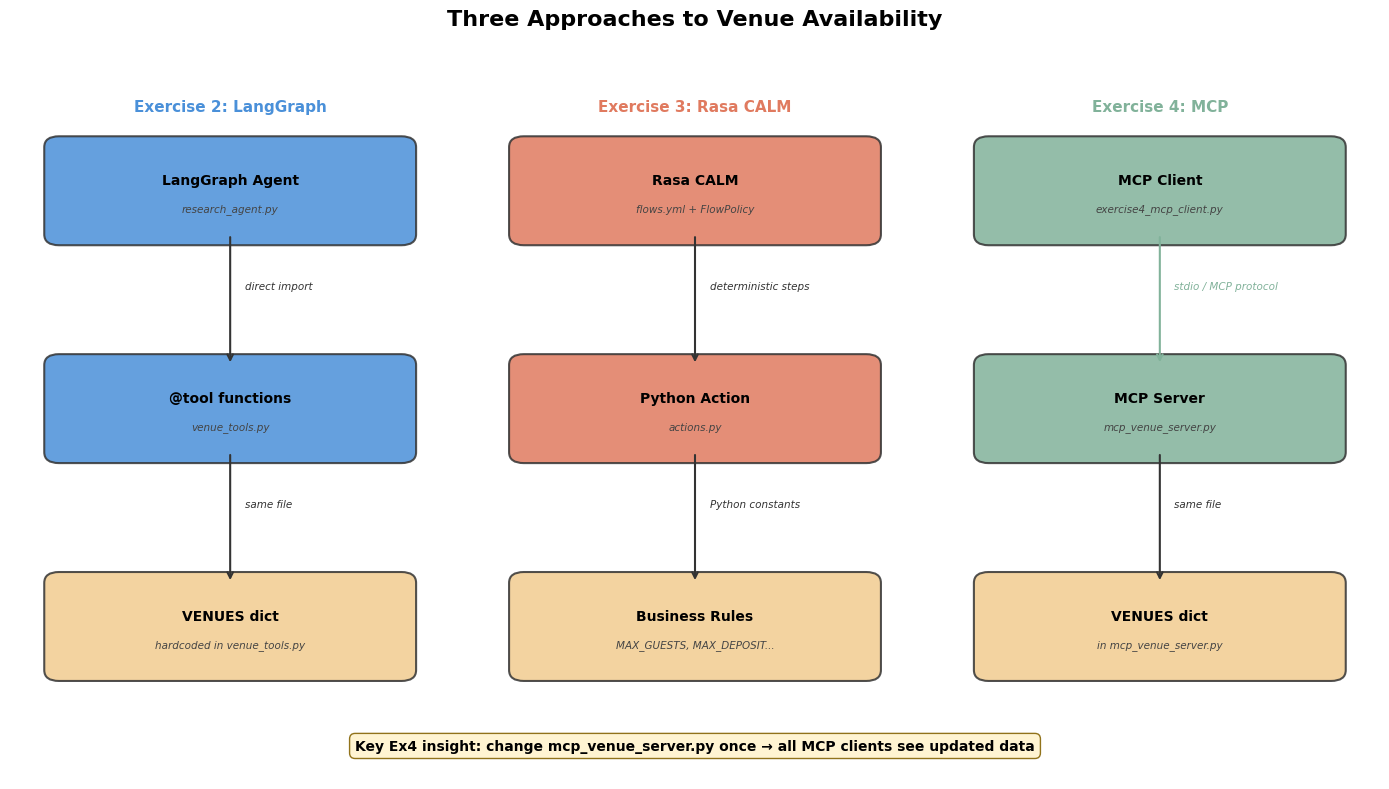

In [2]:
# ── Architecture diagram ─────────────────────────────────────────────────
# Uses matplotlib to visualise how each approach connects to venue data.
# This illustrates the key Exercise 4 lesson: MCP decouples data from clients.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Three Approaches to Venue Availability', fontsize=16, fontweight='bold', pad=20)

# ── Colours ───────────────────────────────────────────────────────────────
c_lang = '#4A90D9'   # LangGraph blue
c_rasa = '#E07A5F'   # Rasa orange
c_mcp  = '#81B29A'   # MCP green
c_data = '#F2CC8F'   # Data yellow

# ── Helper to draw a box ─────────────────────────────────────────────────
def draw_box(x, y, w, h, color, label, sublabel=''):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                                    facecolor=color, edgecolor='#333', linewidth=1.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2 + (0.15 if sublabel else 0), label,
            ha='center', va='center', fontsize=10, fontweight='bold')
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.25, sublabel,
                ha='center', va='center', fontsize=7.5, style='italic', color='#444')

# ── Helper to draw an arrow ──────────────────────────────────────────────
def draw_arrow(x1, y1, x2, y2, label='', color='#333'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx + 0.15, my + 0.15, label, fontsize=7.5, color=color, style='italic')

# ═══════════════════════════════════════════════════════════════════════════
# Column 1: LangGraph (Exercise 2)
# ═══════════════════════════════════════════════════════════════════════════
draw_box(0.5, 7.5, 3.5, 1.2, c_lang, 'LangGraph Agent', 'research_agent.py')
draw_box(0.5, 4.5, 3.5, 1.2, c_lang, '@tool functions', 'venue_tools.py')
draw_box(0.5, 1.5, 3.5, 1.2, c_data, 'VENUES dict', 'hardcoded in venue_tools.py')
draw_arrow(2.25, 7.5, 2.25, 5.7, 'direct import')
draw_arrow(2.25, 4.5, 2.25, 2.7, 'same file')
ax.text(2.25, 9.2, 'Exercise 2: LangGraph', ha='center', fontsize=11, fontweight='bold', color=c_lang)

# ═══════════════════════════════════════════════════════════════════════════
# Column 2: Rasa CALM (Exercise 3)
# ═══════════════════════════════════════════════════════════════════════════
draw_box(5.25, 7.5, 3.5, 1.2, c_rasa, 'Rasa CALM', 'flows.yml + FlowPolicy')
draw_box(5.25, 4.5, 3.5, 1.2, c_rasa, 'Python Action', 'actions.py')
draw_box(5.25, 1.5, 3.5, 1.2, c_data, 'Business Rules', 'MAX_GUESTS, MAX_DEPOSIT...')
draw_arrow(7.0, 7.5, 7.0, 5.7, 'deterministic steps')
draw_arrow(7.0, 4.5, 7.0, 2.7, 'Python constants')
ax.text(7.0, 9.2, 'Exercise 3: Rasa CALM', ha='center', fontsize=11, fontweight='bold', color=c_rasa)

# ═══════════════════════════════════════════════════════════════════════════
# Column 3: MCP (Exercise 4)
# ═══════════════════════════════════════════════════════════════════════════
draw_box(10, 7.5, 3.5, 1.2, c_mcp, 'MCP Client', 'exercise4_mcp_client.py')
draw_box(10, 4.5, 3.5, 1.2, c_mcp, 'MCP Server', 'mcp_venue_server.py')
draw_box(10, 1.5, 3.5, 1.2, c_data, 'VENUES dict', 'in mcp_venue_server.py')
draw_arrow(11.75, 7.5, 11.75, 5.7, 'stdio / MCP protocol', c_mcp)
draw_arrow(11.75, 4.5, 11.75, 2.7, 'same file')
ax.text(11.75, 9.2, 'Exercise 4: MCP', ha='center', fontsize=11, fontweight='bold', color=c_mcp)

# ── Key insight annotation ────────────────────────────────────────────────
ax.text(7, 0.4, 'Key Ex4 insight: change mcp_venue_server.py once → all MCP clients see updated data',
        ha='center', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3cd', edgecolor='#856404', alpha=0.9))

plt.tight_layout()
plt.show()

---

## Setup

Load environment variables and configure the shared LLM connection.

In [3]:
import sys, os, json, asyncio
from pathlib import Path
from dotenv import load_dotenv

# Ensure the project root is on the path so we can import sovereign_agent
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / '.env')

print(f"Project root: {PROJECT_ROOT}")
print(f"NEBIUS_KEY set: {bool(os.getenv('NEBIUS_KEY'))}")

Project root: /Users/dgwalters/ML Projects/nebius-hometasks/sovereign-agent-lab
NEBIUS_KEY set: True


---

## 1. LangGraph: Direct Tool Call (Exercise 2 approach)

In Exercise 2, the tools are **Python functions imported directly** into the agent.
The venue data (the `VENUES` dict) lives inside `venue_tools.py` — the same file
as the tool functions.

```
research_agent.py  →  imports  →  venue_tools.py
                                   ├── VENUES dict (data)
                                   └── check_pub_availability() (logic)
```

This is the simplest approach: one file, direct function calls, no network.

In [4]:
# ── LangGraph approach: direct import of @tool function ──────────────────
#
# This mirrors what research_agent.py does in Exercise 2.
# The tool is a plain Python function decorated with @tool.
# We call it directly — no server, no protocol, no discovery.
#
# Source: sovereign_agent/tools/venue_tools.py

from sovereign_agent.tools.venue_tools import check_pub_availability

# Call the tool exactly as the LangGraph agent would
result_langgraph = check_pub_availability.invoke({
    "pub_name": "The Albanach",
    "required_capacity": 160,
    "requires_vegan": True,
})

# Parse and display
data = json.loads(result_langgraph)
print("=" * 50)
print("  LangGraph: check_pub_availability")
print("=" * 50)
print(json.dumps(data, indent=2))
print(f"\nMeets all constraints: {data['meets_all_constraints']}")

  LangGraph: check_pub_availability
{
  "success": true,
  "pub_name": "The Albanach",
  "address": "2 Hunter Square, Edinburgh",
  "capacity": 180,
  "vegan": true,
  "status": "available",
  "meets_all_constraints": true
}

Meets all constraints: True


---

## 2. Rasa CALM: Deterministic Validation (Exercise 3 approach)

In Exercise 3, Rasa doesn't "search" for venues — it **validates a booking**
using deterministic Python rules. The LLM collects slot values (guest count,
vegan count, deposit), then `ActionValidateBooking` runs hard-coded business
logic.

```
User message  →  LLM picks flow  →  collect slots  →  action_validate_booking
                  (flexible)         (deterministic)    (deterministic Python)
```

There's no venue lookup tool — Rasa's role is to **confirm** a booking,
not to **search** for one. This is a fundamentally different task shape.

Below we simulate what `ActionValidateBooking` does, using the same
business constants from `actions.py`.

In [ ]:
# ── Rasa CALM approach: deterministic business rule validation ────────────
#
# We can't easily call the Rasa action server from a notebook, but we CAN
# reproduce the exact logic from actions.py to show how it works.
#
# Source: exercise3_rasa/actions/actions.py (ActionValidateBooking.run)
#
# Key difference from LangGraph:
#   - No venue search — Rasa validates data the LLM has already collected
#   - Business rules are Python constants, NOT in a prompt
#   - The LLM cannot negotiate around these checks

"""Rasa - it's like a structured conversation wrapper around  
  business logic, where the LLM handles the fuzzy language  
  parts and the flow + Python handle the rigid parts. A plain 
  function doesn't manage a multi-turn dialogue."""

# These constants come from actions.py lines 63-65
MAX_GUESTS      = 170
MAX_DEPOSIT_GBP = 300
MAX_VEGAN_RATIO = 0.80

def validate_booking(guests: float, vegans: float, deposit: float) -> dict:
    """
    Reproduces the logic from ActionValidateBooking.run() in actions.py.
    Returns a dict with booking_valid and rejection_reason.
    """
    # Guard 1: Venue capacity (actions.py line 126)
    if guests > MAX_GUESTS:
        return {"booking_valid": False,
                "reason": f"Guest count ({int(guests)}) exceeds max capacity of {MAX_GUESTS}"}

    # Guard 2: Deposit limit (actions.py line 133)
    if deposit > MAX_DEPOSIT_GBP:
        return {"booking_valid": False,
                "reason": f"Deposit £{deposit:.0f} exceeds limit of £{MAX_DEPOSIT_GBP}"}

    # Guard 3: Vegan ratio (actions.py line 141)
    vegan_ratio = vegans / guests if guests > 0 else 0
    if vegan_ratio > MAX_VEGAN_RATIO:
        return {"booking_valid": False,
                "reason": f"{int(vegans)}/{int(guests)} vegan ({vegan_ratio:.0%}) is unusually high"}

    return {"booking_valid": True, "reason": "All guards passed — booking confirmed"}

# ── Test with the same scenario: 160 guests, 50 vegan, £200 deposit ──────
result_rasa = validate_booking(guests=160, vegans=50, deposit=200)

print("=" * 50)
print("  Rasa CALM: validate_booking")
print("=" * 50)
print(json.dumps(result_rasa, indent=2))

# ── Also show a failing case ──────────────────────────────────────────────
print("\n--- Failing case: deposit too high ---")
result_rasa_fail = validate_booking(guests=160, vegans=50, deposit=500)
print(json.dumps(result_rasa_fail, indent=2))

---

## 3. MCP: Dynamic Tool Discovery (Exercise 4 approach)

In Exercise 4, the tools live on a **separate MCP server** (`mcp_venue_server.py`).
The client doesn't import any tool functions — it **discovers** them at runtime
by connecting to the server and calling `list_tools()`.

```
exercise4_mcp_client.py  →  stdio  →  mcp_venue_server.py
  (discovers tools)          MCP        ├── VENUES dict (data)
  (knows nothing about       protocol   ├── search_venues() 
   venues until runtime)                └── get_venue_details()
```

### Why this matters (Exercise 4 key lesson)

When you changed The Albanach's status from `"available"` to `"full"` in
`mcp_venue_server.py`, the client code (`exercise4_mcp_client.py`) didn't
need any changes — it just got different results.

In the LangGraph approach (Exercise 2), the data lives in `venue_tools.py`
which is tightly coupled to the agent. With MCP, the data and tools live
on a server that **any** MCP-compatible client can connect to.

In [ ]:
# ── MCP approach: connect to server, discover tools, call search_venues ──
#
# This mirrors what exercise4_mcp_client.py does.
# The key difference: we DON'T import anything from mcp_venue_server.py.
# We connect to it as a subprocess and discover tools dynamically.
#
# Source: sovereign_agent/tools/mcp_venue_server.py (the server)
#         week1/exercise4_mcp_client.py (the client pattern)

from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

# Path to the MCP server script
SERVER_SCRIPT = str(PROJECT_ROOT / "sovereign_agent" / "tools" / "mcp_venue_server.py")

async def mcp_search_venues(min_capacity: int, requires_vegan: bool) -> dict:
    """
    Connect to the MCP server, call search_venues, and return results.
    
    Each call starts a fresh server subprocess — this is how Exercise 4's
    _make_mcp_caller works (exercise4_mcp_client.py lines 67-78).
    """
    params = StdioServerParameters(
        command=sys.executable,
        args=[SERVER_SCRIPT]
    )
    async with stdio_client(params) as (r, w):
        async with ClientSession(r, w) as session:
            await session.initialize()
            
            # Step 1: Discover what tools are available
            # This is the dynamic discovery — we don't hardcode tool names
            available = await session.list_tools()
            tool_names = [t.name for t in available.tools]
            print(f"  Discovered tools: {tool_names}")
            
            # Step 2: Call search_venues with our parameters
            result = await session.call_tool(
                "search_venues",
                {"min_capacity": min_capacity, "requires_vegan": requires_vegan}
            )
            return json.loads(result.content[0].text)

# Run the MCP call
# (nest_asyncio needed because Jupyter already has an event loop running)
import nest_asyncio
nest_asyncio.apply()

print("=" * 50)
print("  MCP: search_venues")
print("=" * 50)
result_mcp = asyncio.run(mcp_search_venues(min_capacity=160, requires_vegan=True))
print(json.dumps(result_mcp, indent=2))
print(f"\nVenues found: {result_mcp['count']}")

---

## Side-by-Side Comparison

Let's put the three results together and visualise the differences.

In [ ]:
# ── Side-by-side comparison table ────────────────────────────────────────
#
# This highlights the fundamental differences between the three approaches.
# Each answers a different question:
#   LangGraph: "Does this specific venue meet my needs?"
#   Rasa:      "Is this booking acceptable under our business rules?"
#   MCP:       "Which venues from the server match my criteria?"

comparison = {
    "Property": [
        "Exercise",
        "Question answered",
        "Data source",
        "Tool location",
        "Discovery",
        "Who decides next step?",
        "Can handle unexpected input?",
        "File to change venue data",
    ],
    "LangGraph (Ex 2)": [
        "Exercise 2",
        "Does venue X meet constraints?",
        "VENUES dict in venue_tools.py",
        "venue_tools.py (imported)",
        "Static — hardcoded in TOOLS list",
        "LLM at every step",
        "Yes — LLM can improvise",
        "venue_tools.py",
    ],
    "Rasa CALM (Ex 3)": [
        "Exercise 3",
        "Is this booking within rules?",
        "Python constants in actions.py",
        "actions.py (called by Rasa)",
        "Defined in flows.yml",
        "Flow steps (deterministic)",
        "No — only defined flows",
        "actions.py",
    ],
    "MCP (Ex 4)": [
        "Exercise 4",
        "Which venues match criteria?",
        "VENUES dict in mcp_venue_server.py",
        "mcp_venue_server.py (separate process)",
        "Dynamic — list_tools() at runtime",
        "LLM at every step",
        "Yes — LLM can improvise",
        "mcp_venue_server.py (clients unchanged!)",
    ],
}

# Display as a formatted table
# Using pandas if available, otherwise plain text
try:
    import pandas as pd
    df = pd.DataFrame(comparison).set_index("Property")
    display(df)
except ImportError:
    # Fallback: plain text table
    for i, prop in enumerate(comparison["Property"]):
        print(f"\n{prop}:")
        for col in ["LangGraph (Ex 2)", "Rasa CALM (Ex 3)", "MCP (Ex 4)"]:
            print(f"  {col}: {comparison[col][i]}")

In [ ]:
# ── Data coupling diagram ────────────────────────────────────────────────
#
# This visualises the Exercise 4 experiment:
# What happens when you change The Albanach's status?
#
# In LangGraph: you must change venue_tools.py (same file the agent imports)
# In MCP:       you change mcp_venue_server.py (clients stay untouched)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax in (ax1, ax2):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis('off')

# ── Left: LangGraph (tightly coupled) ────────────────────────────────────
ax1.set_title('LangGraph: Tightly Coupled', fontsize=13, fontweight='bold', color=c_lang)

# Agent box
r1 = mpatches.FancyBboxPatch((1, 5.5), 8, 1.5, boxstyle='round,pad=0.15',
                              facecolor=c_lang, edgecolor='#333', linewidth=1.5, alpha=0.85)
ax1.add_patch(r1)
ax1.text(5, 6.25, 'research_agent.py', ha='center', va='center', fontsize=10, fontweight='bold')

# venue_tools.py box (contains BOTH tools and data)
r2 = mpatches.FancyBboxPatch((1, 1.5), 8, 3, boxstyle='round,pad=0.15',
                              facecolor='#dce6f2', edgecolor='#333', linewidth=1.5)
ax1.add_patch(r2)
ax1.text(5, 3.8, 'venue_tools.py', ha='center', va='center', fontsize=10, fontweight='bold')
ax1.text(5, 3.0, '@tool functions + VENUES dict', ha='center', va='center', fontsize=9, style='italic')

# Highlight: data change requires touching this file
r3 = mpatches.FancyBboxPatch((2, 2.0), 6, 0.7, boxstyle='round,pad=0.1',
                              facecolor='#ffe0e0', edgecolor='#c0392b', linewidth=2, linestyle='--')
ax1.add_patch(r3)
ax1.text(5, 2.35, 'Change data here = same file agent imports', ha='center', fontsize=8, color='#c0392b')

ax1.annotate('', xy=(5, 4.5), xytext=(5, 5.5),
             arrowprops=dict(arrowstyle='->', color='#333', lw=2))
ax1.text(5.2, 5.0, 'import', fontsize=9, color='#333')

# ── Right: MCP (decoupled) ───────────────────────────────────────────────
ax2.set_title('MCP: Decoupled (Exercise 4)', fontsize=13, fontweight='bold', color=c_mcp)

# Client box
r4 = mpatches.FancyBboxPatch((0.5, 5.5), 4, 1.5, boxstyle='round,pad=0.15',
                              facecolor=c_mcp, edgecolor='#333', linewidth=1.5, alpha=0.85)
ax2.add_patch(r4)
ax2.text(2.5, 6.25, 'MCP Client', ha='center', va='center', fontsize=10, fontweight='bold')

# Another client box
r5 = mpatches.FancyBboxPatch((5.5, 5.5), 4, 1.5, boxstyle='round,pad=0.15',
                              facecolor=c_rasa, edgecolor='#333', linewidth=1.5, alpha=0.85)
ax2.add_patch(r5)
ax2.text(7.5, 6.25, 'Another Client', ha='center', va='center', fontsize=10, fontweight='bold')
ax2.text(7.5, 5.85, '(Rasa, other agent...)', ha='center', va='center', fontsize=8, style='italic')

# Server box
r6 = mpatches.FancyBboxPatch((1, 1.5), 8, 2.5, boxstyle='round,pad=0.15',
                              facecolor='#d4edda', edgecolor='#333', linewidth=1.5)
ax2.add_patch(r6)
ax2.text(5, 3.5, 'mcp_venue_server.py', ha='center', va='center', fontsize=10, fontweight='bold')
ax2.text(5, 2.8, '@mcp.tool() functions + VENUES dict', ha='center', va='center', fontsize=9, style='italic')

# Highlight: data change only here
r7 = mpatches.FancyBboxPatch((2, 1.8), 6, 0.7, boxstyle='round,pad=0.1',
                              facecolor='#d4edda', edgecolor='#27ae60', linewidth=2, linestyle='--')
ax2.add_patch(r7)
ax2.text(5, 2.15, 'Change data here = clients untouched!', ha='center', fontsize=8, color='#27ae60')

# Arrows
ax2.annotate('', xy=(3, 4), xytext=(2.5, 5.5),
             arrowprops=dict(arrowstyle='->', color=c_mcp, lw=2))
ax2.annotate('', xy=(7, 4), xytext=(7.5, 5.5),
             arrowprops=dict(arrowstyle='->', color=c_rasa, lw=2))
ax2.text(1.8, 4.8, 'MCP\nprotocol', fontsize=8, color=c_mcp, ha='center')
ax2.text(8.2, 4.8, 'MCP\nprotocol', fontsize=8, color=c_rasa, ha='center')

plt.tight_layout()
plt.show()

---

## Summary

| | LangGraph (Ex 2) | Rasa CALM (Ex 3) | MCP (Ex 4) |
|---|---|---|---|
| **Flexibility** | High — LLM decides everything | Low — flows are fixed | High — LLM decides everything |
| **Predictability** | Low — can loop or hallucinate | High — deterministic steps | Low — same as LangGraph |
| **Data coupling** | Tight — tools + data in one file | N/A — no venue search | Loose — server is separate |
| **Multi-client** | No — tools are Python imports | No — Rasa-specific | Yes — any MCP client connects |
| **Best for** | Exploration, research tasks | Business rule enforcement | Shared tool infrastructure |